# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [42]:
df.count()

Trip ID              144015
Duration             144015
Start Date           144015
Start Station        144015
Start Terminal       144015
End Date             144015
End Station          144015
End Terminal         144015
Bike #               144015
Subscription Type    144015
Zip Code             137885
dtype: int64

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [43]:
# make a copy of your DataFrame
df2 = df.copy()
# make a list column names
cols = df2.columns.tolist()
# replace space with _
cols = [col.replace(' ', '_').replace('#','num').lower() for col in cols]
# reassign new column names to DataFrame
df2.columns = cols
print(df2.columns)

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')


How many types of subscription options are there? What are the different subscription types?

In [44]:
print(df2['subscription_type'].unique())
print(df2['subscription_type'].nunique())

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str
2


What is the frequency of each subscription option?

In [45]:
df2

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2/28/2014 22:15,Powell Street BART,39,2/28/2014 22:22,South Van Ness at Market,66,483,Subscriber,94404
144011,198772,145,2/28/2014 22:38,Commercial at Montgomery,45,2/28/2014 22:40,Davis at Jackson,42,425,Subscriber,94111
144012,198773,677,2/28/2014 22:45,Embarcadero at Sansome,60,2/28/2014 22:56,Market at 4th,76,438,Subscriber,94102
144013,198774,64128,2/28/2014 23:01,Civic Center BART (7th at Market),72,3/1/2014 16:50,Harry Bridges Plaza (Ferry Building),50,414,Customer,94124


Please plot the frequency of each subscription option with a pie chart:

<Axes: >

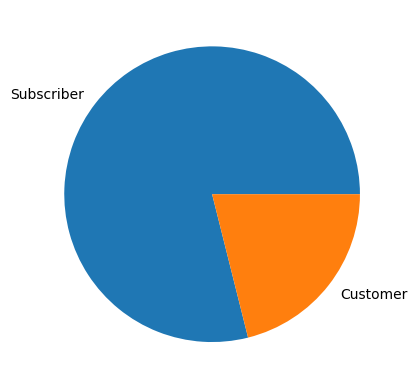

In [46]:
df2['subscription_type'].value_counts().plot.pie()

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

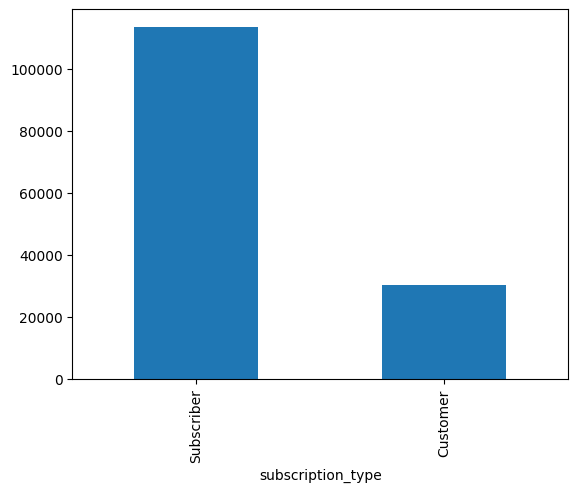

In [47]:
df2['subscription_type'].value_counts().plot.bar()

Have a look at the start_station column: Which 10 stations occur most frequently?

In [48]:
df2['start_station'].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [49]:
df2['end_station'].value_counts().tail(10)

end_station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [ ]:
pd.crosstab(df2['start_station'], df2['subscription_type'], margins=True)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [64]:
print(df2['duration'].min())
print(df2[df2['duration'] == df2['duration'].min()]['trip_id'].nunique())

60
17


What do you think is going on with the short trips?

In [ ]:
# minimum time evaluation seems 1 min

What is the longest trip?

In [66]:
df2[df2['duration'] == df2['duration'].max()]

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
80510,111309,722236,11/30/2013 13:29,University and Emerson,35,12/8/2013 22:06,University and Emerson,35,247,Customer,94301


In [ ]:
# not correctly booked or got lost/forgotten?

How would you define a "long" trip? How many trips are "long" according to your definition?

In [74]:
# long in sense of lost/forgotten more than 1 day
print(df2[df2['duration'] > 86400].count()['trip_id'])
print(df2.count()['trip_id'])
print(df2[df2['duration'] > 86400].count()['trip_id'] / df2.count()['trip_id'] * 100)

82
144015
0.056938513349303894


Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

In [ ]:
# 0.06% seem to forget to bring the bikes back?

Plot the duration column.

<Axes: >

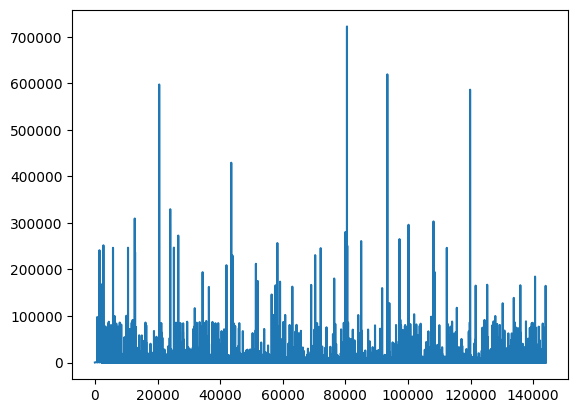

In [73]:
df2['duration'].plot()

Does this plot give any insights?

In [ ]:
# no x is index of table y is duration

Select subsections of the data to make plots that provide more insights.

<Axes: >

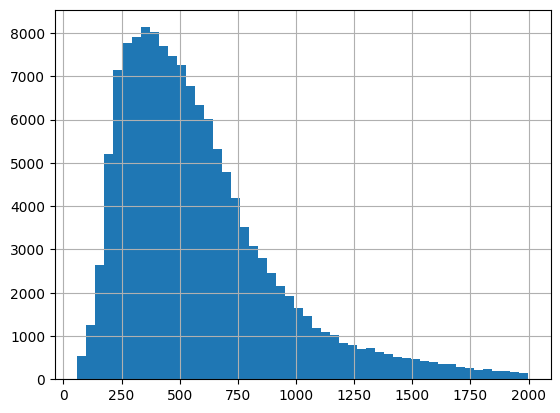

In [83]:
df2[df2['duration'] < 2000]['duration'].hist(bins=50)

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [92]:
df2['end_station']=df2['end_station'].str.replace(' ', '_').str.lower()
df2['start_station']=df2['start_station'].str.replace(' ', '_').str.lower()
df2

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2/28/2014 22:15,powell_street_bart,39,2/28/2014 22:22,south_van_ness_at_market,66,483,Subscriber,94404
144011,198772,145,2/28/2014 22:38,commercial_at_montgomery,45,2/28/2014 22:40,davis_at_jackson,42,425,Subscriber,94111
144012,198773,677,2/28/2014 22:45,embarcadero_at_sansome,60,2/28/2014 22:56,market_at_4th,76,438,Subscriber,94102
144013,198774,64128,2/28/2014 23:01,civic_center_bart_(7th_at_market),72,3/1/2014 16:50,harry_bridges_plaza_(ferry_building),50,414,Customer,94124


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 

In [93]:
df2

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2/28/2014 22:15,powell_street_bart,39,2/28/2014 22:22,south_van_ness_at_market,66,483,Subscriber,94404
144011,198772,145,2/28/2014 22:38,commercial_at_montgomery,45,2/28/2014 22:40,davis_at_jackson,42,425,Subscriber,94111
144012,198773,677,2/28/2014 22:45,embarcadero_at_sansome,60,2/28/2014 22:56,market_at_4th,76,438,Subscriber,94102
144013,198774,64128,2/28/2014 23:01,civic_center_bart_(7th_at_market),72,3/1/2014 16:50,harry_bridges_plaza_(ferry_building),50,414,Customer,94124


In [ ]:
#different zip codes
df2['zip_code'].nunique()

2880

<Axes: xlabel='start_date'>

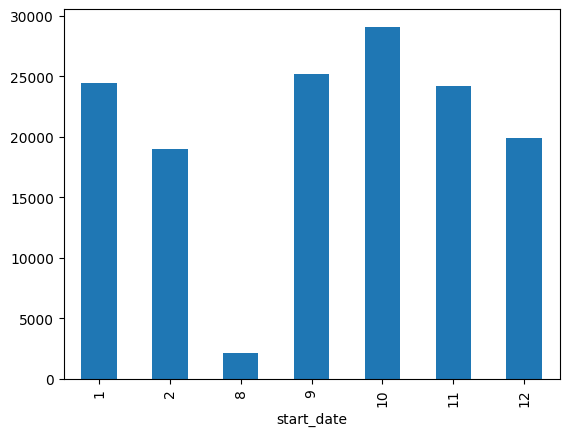

In [ ]:
# Plot start_date over months
df2['start_date'] = pd.to_datetime(df2['start_date'])
df2['start_date'].dt.month.value_counts().sort_index().plot(kind='bar')